In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.colors as colors
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)

In [2]:
# --- read mask

# input mask - Miocene
ds_mask = xr.open_dataset('../Miocene_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Mio, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

# ==================================================================
# input mask - Preindustrial
ds_mask = xr.open_dataset('../Preindustrial_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Pi, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

In [3]:
lat = ds_mask['lat']
lon = ds_mask['lon']
weights = np.cos(np.deg2rad(lat))

In [4]:
# --- read data ---
ds = xr.open_dataset('./Fig7_AnoTOA_Comparison.nc')

In [5]:
# --- input: Miocene Geographic Effects ---
avg_net_PiDust_GeoDiff = ds['MioGeo_NetTOA_ano']
avg_net_PiDust_GeoDiff_yr = ds['MioGeo_NetTOA_ano_annual']

net_PiDust_GeoDiff_mean = avg_net_PiDust_GeoDiff.weighted(weights).mean(dim=['lon','lat']) 
net_PiDust_GeoDiff_std = avg_net_PiDust_GeoDiff_yr.std(dim=['year'])

# --- input: 2xCO2 Effects ---
avg_net_CO2_Diff = ds['CO2_NetTOA_ano']
avg_net_CO2_Diff_yr = ds['CO2_NetTOA_ano_annual']

net_CO2_Diff_mean = avg_net_CO2_Diff.weighted(weights).mean(dim=['lon','lat']) 
net_CO2_Diff_std = avg_net_CO2_Diff_yr.std(dim=['year'])

# --- input: Miocene Dust Effects (under PI scenario) ---
avg_net_PP_Diff = ds['PI_NetTOA_ano']
avg_net_PP_Diff_yr = ds['PI_NetTOA_ano_annual']

net_PP_Diff_mean = avg_net_PP_Diff.weighted(weights).mean(dim=['lon','lat']) 
net_PP_Diff_std = avg_net_PP_Diff_yr.std(dim=['year'])

# --- input: Miocene Dust Effects (under PI scenario) ---
avg_net_MM_Diff = ds['Mio_NetTOA_ano']
avg_net_MM_Diff_yr = ds['Mio_NetTOA_ano_annual']

net_MM_Diff_mean = avg_net_MM_Diff.weighted(weights).mean(dim=['lon','lat']) 
net_MM_Diff_std = avg_net_MM_Diff_yr.std(dim=['year'])

In [7]:
pattern_Diff = np.empty((4, lat.size, lon.size))
pattern_Diff = xr.DataArray(data=pattern_Diff, dims=['var','lat','lon'], coords=[np.arange(1,4.5,1), lat, lon])
pattern_Diff[0,:,:] = avg_net_PiDust_GeoDiff
pattern_Diff[1,:,:] = avg_net_CO2_Diff
pattern_Diff[2,:,:] = avg_net_PP_Diff
pattern_Diff[3,:,:] = avg_net_MM_Diff

# Add cyclic point to data
data = pattern_Diff
data, lons = add_cyclic_point(data, coord=lon)

''

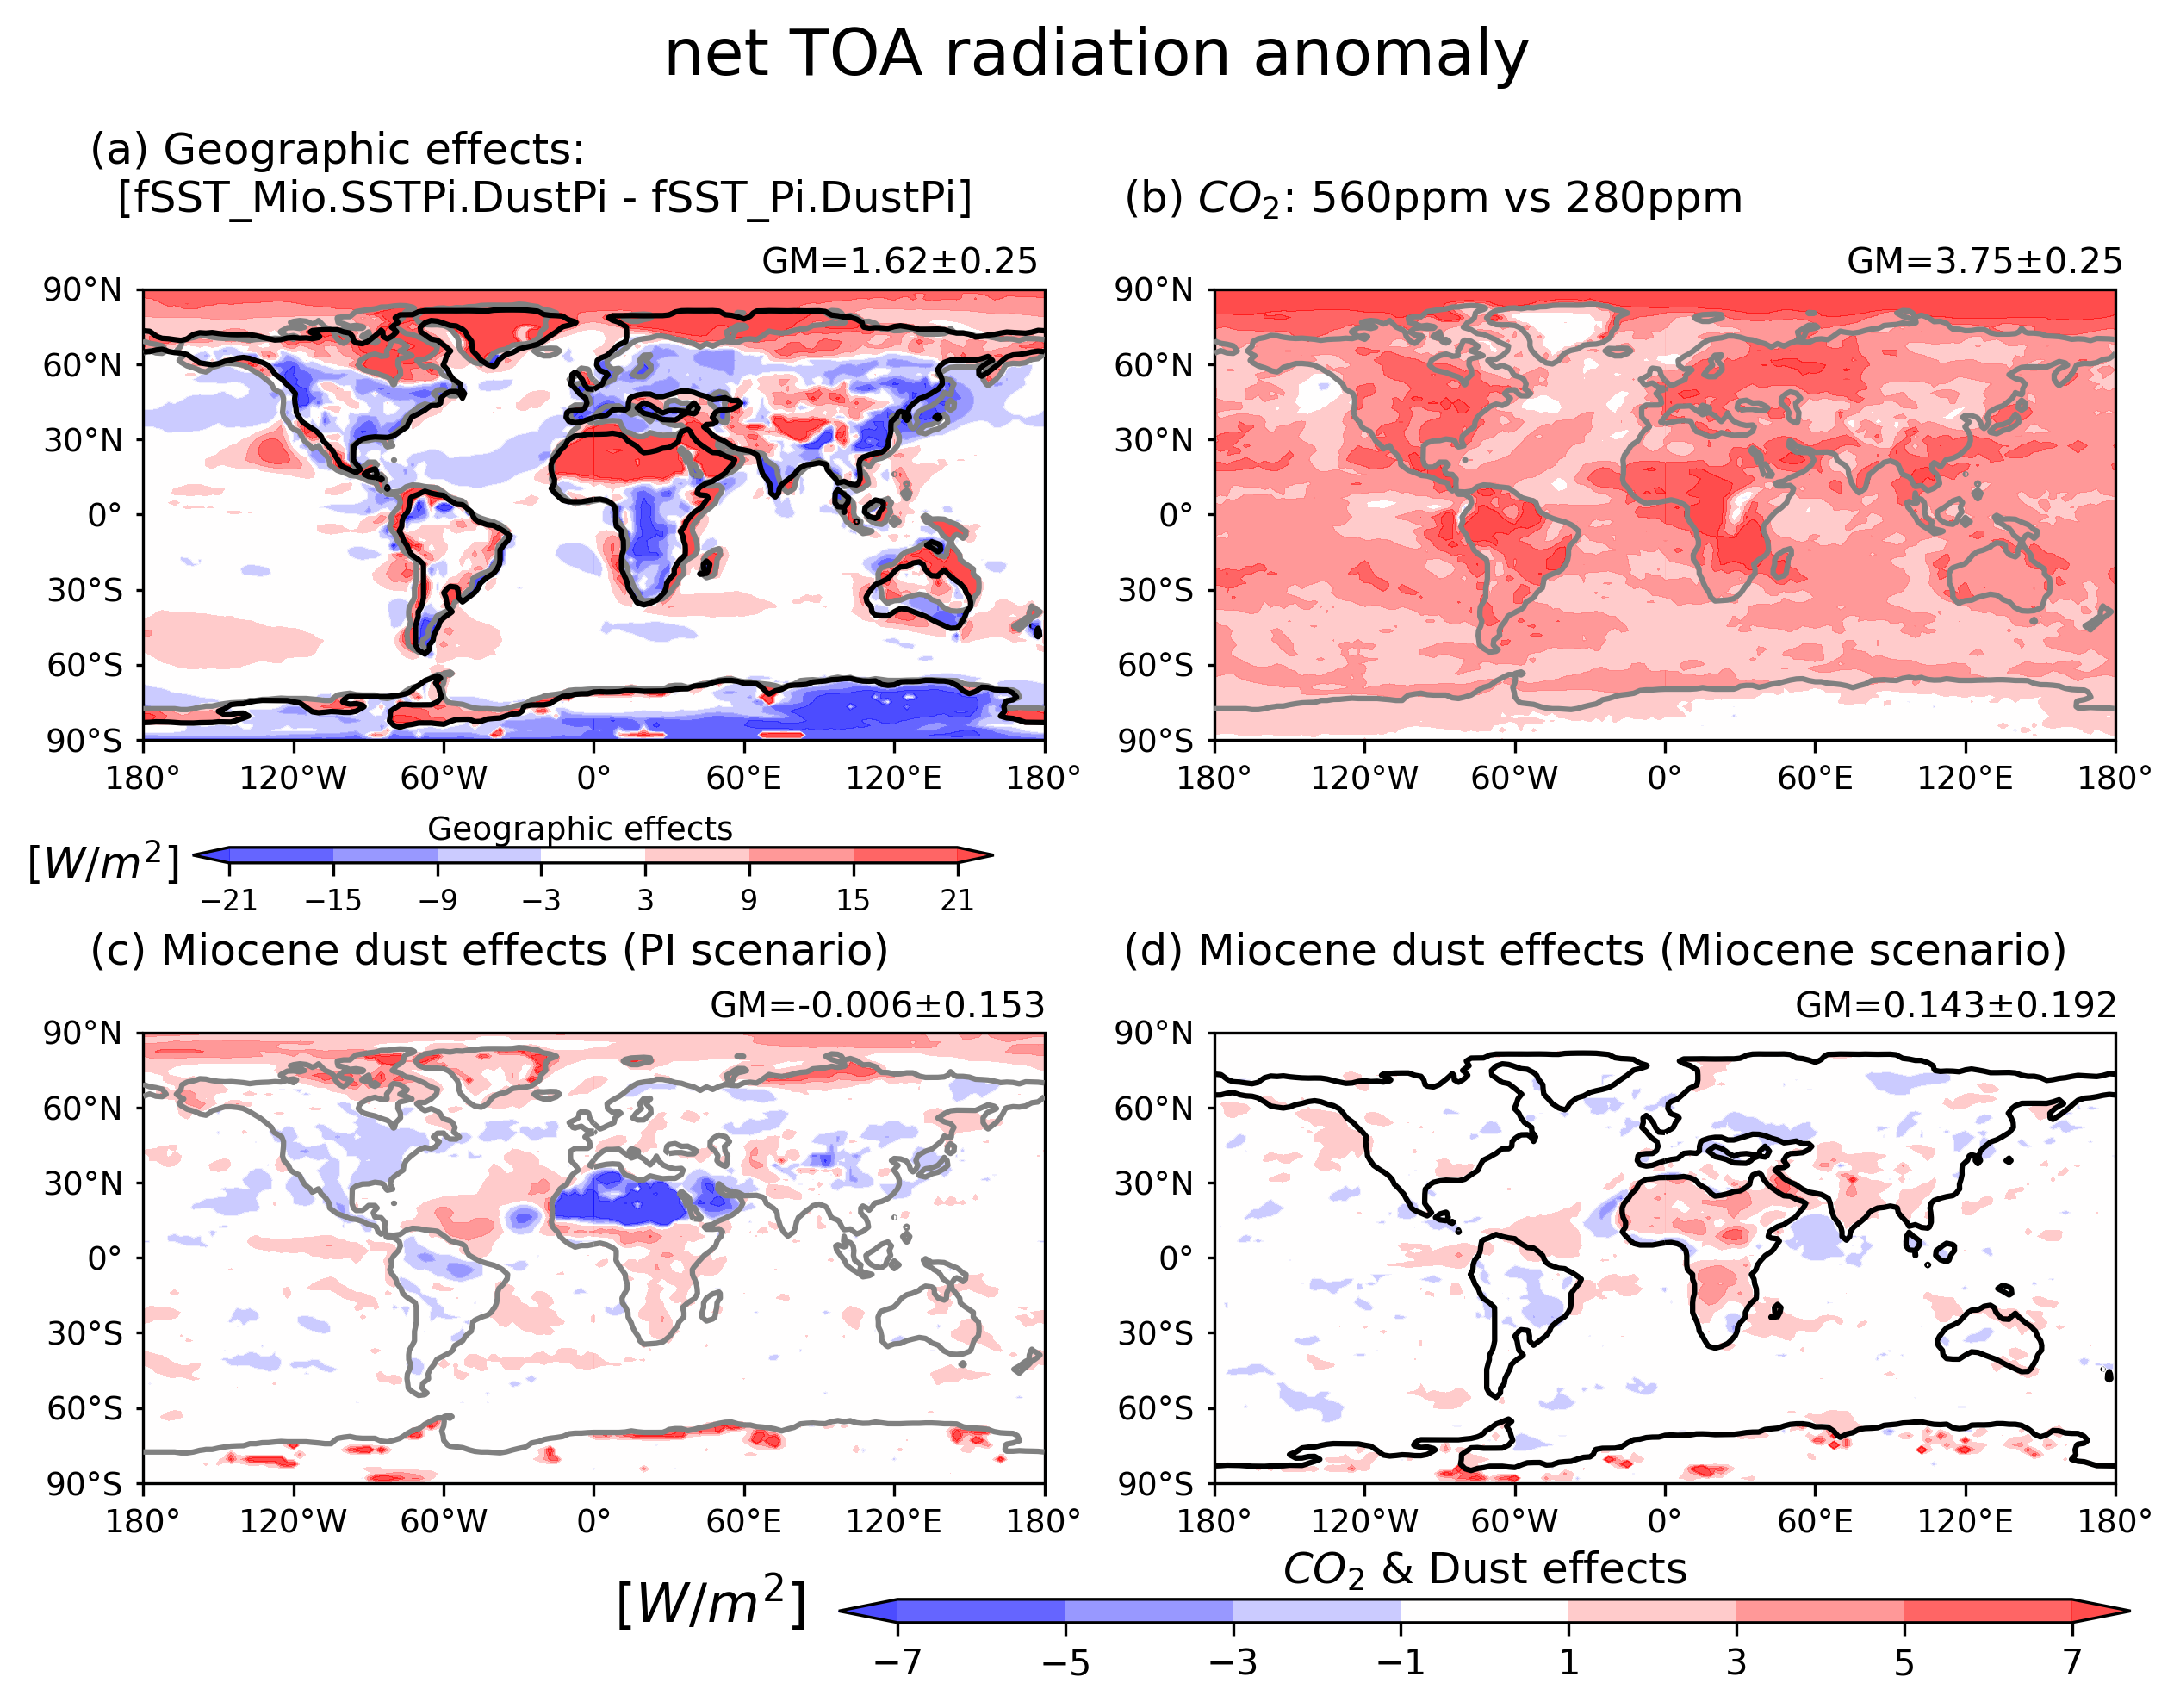

In [9]:
# --- plot ---

# Define the figure and each axis for the 2 rows and 2 columns
fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                        figsize=(10,6), dpi=300)
    
# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.15, hspace=0.65) 

axs = axs.flatten()

for i,m in enumerate(pattern_Diff['var']):
        
    # Contour plot
    if i==0:
        cs1=axs[i].contourf(lons,lat,data[i,:,:], levels = np.linspace(-21, 21, 8),
                    transform = ccrs.PlateCarree(), cmap='bwr', alpha=0.7, extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.4,1.6],
                       transform = ccrs.PlateCarree(), colors='grey', linewidths=1.5, zorder=3)
        # Add coastines in Miocene Scenario
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=4)
    elif i==3:
        cs2=axs[i].contourf(lons,lat,data[i,:,:], levels = np.linspace(-7, 7, 8),
                            transform = ccrs.PlateCarree(), cmap='bwr', alpha=0.7, extend='both')
        # Add coastines in Miocene Scenario
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=3)
    else:
        cs2=axs[i].contourf(lons,lat,data[i,:,:], levels = np.linspace(-7, 7, 8),
                            transform = ccrs.PlateCarree(), cmap='bwr', alpha=0.7, extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.4,1.6],
                       transform = ccrs.PlateCarree(), colors='grey', linewidths=1.5, zorder=3)
    
    # Longitude labels
    axs[i].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()  
    axs[i].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
    axs[i].tick_params(axis='y', size=2)             # set xtick parameters
    for xlabel in axs[i].get_xticklabels():          # set xticks_label
        xlabel.set_fontsize(9)        

    # Latitude labels
    axs[i].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
    lat_formatter = cticker.LatitudeFormatter()
    axs[i].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
    axs[i].tick_params(axis='y', size=2)             # set ytick parameters
    for ylabel in axs[i].get_yticklabels():          # set yticks_label
        ylabel.set_fontsize(9)        
        
        
    # Title each subplot with the name of the month
    # axs[i].set_title(title[i])
          
    # Add gridlines
    # axs[i].gridlines(colors='white', linewidths=0.2, zorder=2)

# -----------------------------------------------------------------------
# Add colorbar for Geo-Effects
cax1 = fig.add_axes([0.15, 0.51, 0.31, 0.01])    # set the [x0, y0, width, height] of the colorbar
CB1  = plt.colorbar(cs1, cax=cax1, orientation='horizontal')
CB1.ax.tick_params(labelsize=8)
# Add colorbar for 2xCO2-Effects & Miocene Dust Effects
cax2 = fig.add_axes([0.4, 0.02, 0.5, 0.015])    # set the [x0, y0, width, height] of the colorbar
CB2  = plt.colorbar(cs2, cax=cax2, orientation='horizontal')
CB2.ax.tick_params(labelsize=10)
    
# Add colobar's title
GM_PiDust = 'GM='+str('{:03.2f}'.format(net_PiDust_GeoDiff_mean.values))+'±'+str('{:03.2f}'.format(net_PiDust_GeoDiff_std.values))
GM_CO2 = 'GM='+str('{:03.2f}'.format(net_CO2_Diff_mean.values))+'±'+str('{:03.2f}'.format(net_CO2_Diff_std.values))
GM_PP = 'GM='+str('{:03.3f}'.format(net_PP_Diff_mean.values))+'±'+str('{:03.3f}'.format(net_PP_Diff_std.values))
GM_MM = 'GM='+str('{:03.3f}'.format(net_MM_Diff_mean.values))+'±'+str('{:03.3f}'.format(net_MM_Diff_std.values))

plt.figtext(0.3,0.525,'Geographic effects',ha='center',fontsize=9)
plt.figtext(0.115,0.5,'[$W/m^2$]',ha='center',fontsize=12)
plt.figtext(0.65,0.045,'$CO_2$ & Dust effects',ha='center',fontsize=12)
plt.figtext(0.35,0.02,'[$W/m^2$]',ha='center',fontsize=15)
plt.figtext(0.11,0.93,'(a) Geographic effects:\n  [fSST_Mio.SSTPi.DustPi - fSST_Pi.DustPi]',fontsize=12)
plt.figtext(0.37,0.89,GM_PiDust,fontsize=10)
plt.figtext(0.51,0.93,'(b) $CO_2$: 560ppm vs 280ppm',fontsize=12)
plt.figtext(0.79,0.89,GM_CO2,fontsize=10)
plt.figtext(0.11,0.445,'(c) Miocene dust effects (PI scenario)',fontsize=12)
plt.figtext(0.35,0.41,GM_PP,fontsize=10)
plt.figtext(0.51,0.445,'(d) Miocene dust effects (Miocene scenario)',fontsize=12)
plt.figtext(0.77,0.41,GM_MM,fontsize=10)


# Add title
plt.suptitle('net TOA radiation anomaly', y=1.05, fontsize=18)
# fig.savefig('plot_TS.png')
;